# Importing Measured Data - Fed-Batch Bioreactor

The other gallery examples generate synthetic training data with `generate_data()` directly in the script. This notebook walks through training a hybrid model from real measurements (for example, a CSV exported from a lab notebook or process historian), before checking that the trained model makes physically feasible predictions under new operating conditions.

The system is the fed-batch bioreactor from {cite}`kantor2021`, with four states (biomass $X$, product $P$, substrate $S$, and reactor volume $V$):

$$
\begin{align}
\frac{dX}{dt} &= \mu X - \frac{F}{V}X \tag{1}\\
\frac{dP}{dt} &= Y_{px}\,\mu X - \frac{F}{X}P \tag{2}\\
\frac{dS}{dt} &= \frac{F}{V}(S_f - S) - \frac{\mu X}{Y_{xs}} \tag{3}\\
\frac{dV}{dt} &= F \tag{4}
\end{align}
$$

The unknown term is the specific growth rate $\mu$, which we replace with a neural network of the measured states:

$$
\mu(t) = f_{NN}\big(X, P, S, V;\ \theta\big) \tag{5}
$$

For this bioreactor the true kinetics happen to be the Monod law, $\mu = \mu_{max}\, S / (K_s + S)$. We deliberately treat that law as **unknown** and learn $\mu$ from data instead, mirroring the realistic case where the growth kinetics of a strain have not been characterised. The Monod expression is kept only so we can sanity-check the learned rate at the end.

The notebook proceeds in two parts:

1. Load measured data and train the hybrid model.
2. Predict new batches at unseen initial conditions and confirm the trajectories stay physically feasible.

Let's start with the required imports. Note `pandas`, which we use to read the measurement CSV.

In [1]:
%matplotlib inline

import logging

import jax
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyomo.environ as pyo
import pyomo.dae as dae

from sindae.problem import ProblemDefinition
from sindae.nn_utils import SimpleMLP
from sindae.algorithms.smoother import SmootherConfig
from sindae.algorithms.pretrain import PretrainConfig
from sindae.algorithms.simultaneous.train import SimultaneousConfig
from sindae.solvers import SolverConfig
from sindae.plot_utils import plot_instance_data
from sindae import HybridDAE

jax.config.update('jax_enable_x64', True)
logging.basicConfig(level=logging.INFO, format='%(message)s')
logging.getLogger('pyomo').setLevel(logging.ERROR)
logging.getLogger('cyipopt').setLevel(logging.WARNING)
logger = logging.getLogger(__name__)

## Defining the problem

The system is a `ProblemDefinition` subclass implementing three methods: `build_trajectory()` writes the ODEs and fixes the initial charge, `get_input_vars()` returns the states that feed the network, and `get_output_vars()` returns the growth rate the network produces. Because we are treating the kinetics as unknown, the problem contains no expression for $\mu$ since the network will predict it.

In [2]:
class FedBatchBioreactorProblem(ProblemDefinition):
    def __init__(
        self,
        ## Additional args ##
        params,
        ## ProblemDefinition args ##
        ics,
        input_dim,
        z_dim,
        t_span,
        nfe,
        ncp,
        obs_times=None,
        obs_values=None,
        obs_dim=None,
    ):
        super().__init__(ics, input_dim, z_dim, t_span, nfe, ncp,
                         obs_times, obs_values, obs_dim)
        self.params = params

    def build_trajectory(self, block, traj_idx):
        p  = self.params
        t0 = self.t_span[0]
        x0 = self.ics[traj_idx]
        Sf = float(x0[2])        # feed concentration = initial substrate

        block.t    = dae.ContinuousSet(bounds=self.t_span)
        block.x    = pyo.Var(block.t, range(self.input_dim),
                             domain=pyo.NonNegativeReals, initialize=1.0)
        block.z    = pyo.Var(block.t, range(self.z_dim), initialize=0.1)
        block.dxdt = dae.DerivativeVar(block.x, wrt=block.t)

        Feed, Ypx, Yxs = p['Feed'], p['Ypx'], p['Yxs']

        ## Differential Equation ##
        @block.Constraint(block.t, range(self.input_dim))
        def diffeq(b, t, s):
            mu = b.z[t, 0]      # growth rate (learned by the NN)
            X, P, S, V = b.x[t, 0], b.x[t, 1], b.x[t, 2], b.x[t, 3]
            if s == 0:
                # Eqn (1)
                return b.dxdt[t, 0] == mu * X - Feed * (X / V)              
            elif s == 1:
                # Eqn (2)
                return b.dxdt[t, 1] == Ypx * mu * X - Feed * (P / X)        
            elif s == 2:
                # Eqn (3)
                return b.dxdt[t, 2] == Feed * (Sf - S) / V - mu * (X / Yxs) 
            else:
                # Eqn (4)
                return b.dxdt[t, 3] == Feed                                

        # Initial charge of each batch
        for j in range(self.input_dim):
            block.x[t0, j].fix(float(x0[j]))

    def get_input_vars(self, block, t):
        return [block.x[t, j] for j in range(self.input_dim)]

    def get_output_vars(self, block, t):
        return [block.z[t, 0]]

The mechanistic parameters (yields and feed rate). We also keep the true Monod constants `Ks` and `mu_max`. Note that the training workflow never touches them, but we draw the true Monod curve at the end to check the learned rate.

In [3]:
FB_PARAMS = {
    'Feed':   0.05,   # F:      volumetric feed rate
    'Ypx':    0.2,    # P:      product yield
    'Yxs':    0.5,    # Y_ks:   substrate yield
    'Ks':     1.0,    # K_s:    Monod half-saturation (kept only for the final check)
    'mu_max': 0.2,    # mu_max: Monod max growth rate (kept only for the final check)
}

STATE_NAMES = ['$X$ (biomass)', '$P$ (product)', '$S$ (substrate)', '$V$ (volume)']
OUTPUT_NAME = [r'$\mu$ (growth rate)']
SEED = 0

## Step 1 - Load the measured data

Assume `fedbatch_measurements.csv` contains raw experimental data.

A `ProblemDefinition` expects two parallel lists, one entry per trajectory (batch):

| attribute | type | shape per batch |
|-----------|------|-----------------|
| `obs_times`  | list of arrays | `(n_samples,)` |
| `obs_values` | list of arrays | `(n_samples, n_measured_states)` |

So we group the table by `batch`, sort by `time`, and pull the time column and the state columns out as NumPy arrays.

In [4]:
MEASURED_COLS = ['X', 'P', 'S', 'V']   # CSV columns besides 'batch' and 'time'

raw = pd.read_csv('fedbatch_measurements.csv')

obs_times  = []
obs_values = []
for batch_id in sorted(raw['batch'].unique()):
    batch = raw[raw['batch'] == batch_id].sort_values('time')
    obs_times.append(batch['time'].to_numpy())
    obs_values.append(batch[MEASURED_COLS].to_numpy())

print(f'Loaded {len(obs_times)} batches')
for b, (t, v) in enumerate(zip(obs_times, obs_values)):
    print(f'  batch {b}: {v.shape[0]} samples, values shape {v.shape}')

Loaded 3 batches
  batch 0: 31 samples, values shape (31, 4)
  batch 1: 31 samples, values shape (31, 4)
  batch 2: 31 samples, values shape (31, 4)


Then attach the measurements to a problem instance. The initial conditions of each batch is a known quantity set when starting the reactor. Thus, they are supplied directly through `BATCH_ICS`. Next, we set a training discretization domain as in the other example notebooks, again noting that the discretisation used for fitting need not match however the data was sampled.

In [5]:
## Known initial charge [X, P, S, V] of each logged batch ##
BATCH_ICS = np.array([
    [0.05,  0.0, 10.0, 1.00],   # batch 0
    [0.025, 0.0,  5.0, 0.80],   # batch 1
    [0.5,   0.0,  7.5, 0.95],   # batch 2
])

# NN Dims
INPUT_DIM = 4
Z_DIM = 1

# Timespan
T_SPAN = (0.0, 40.0)

# Training discretization scheme
NFE_TRAIN  = 40
NCP_TRAIN  = 3

# Data info
OBS_DIM = 4

problem = FedBatchBioreactorProblem(
    # Additional args
    params=FB_PARAMS,
    # ProblemDefinition args
    ics=BATCH_ICS,
    input_dim=INPUT_DIM, 
    z_dim=Z_DIM, 
    t_span=T_SPAN,
    nfe=NFE_TRAIN, 
    ncp=NCP_TRAIN, 
    # Real data args
    obs_dim=OBS_DIM,
    obs_times=obs_times,    # Measurements from CSV
    obs_values=obs_values   # Measurements from CSV
)

A quick look at the raw measurements for each batch:

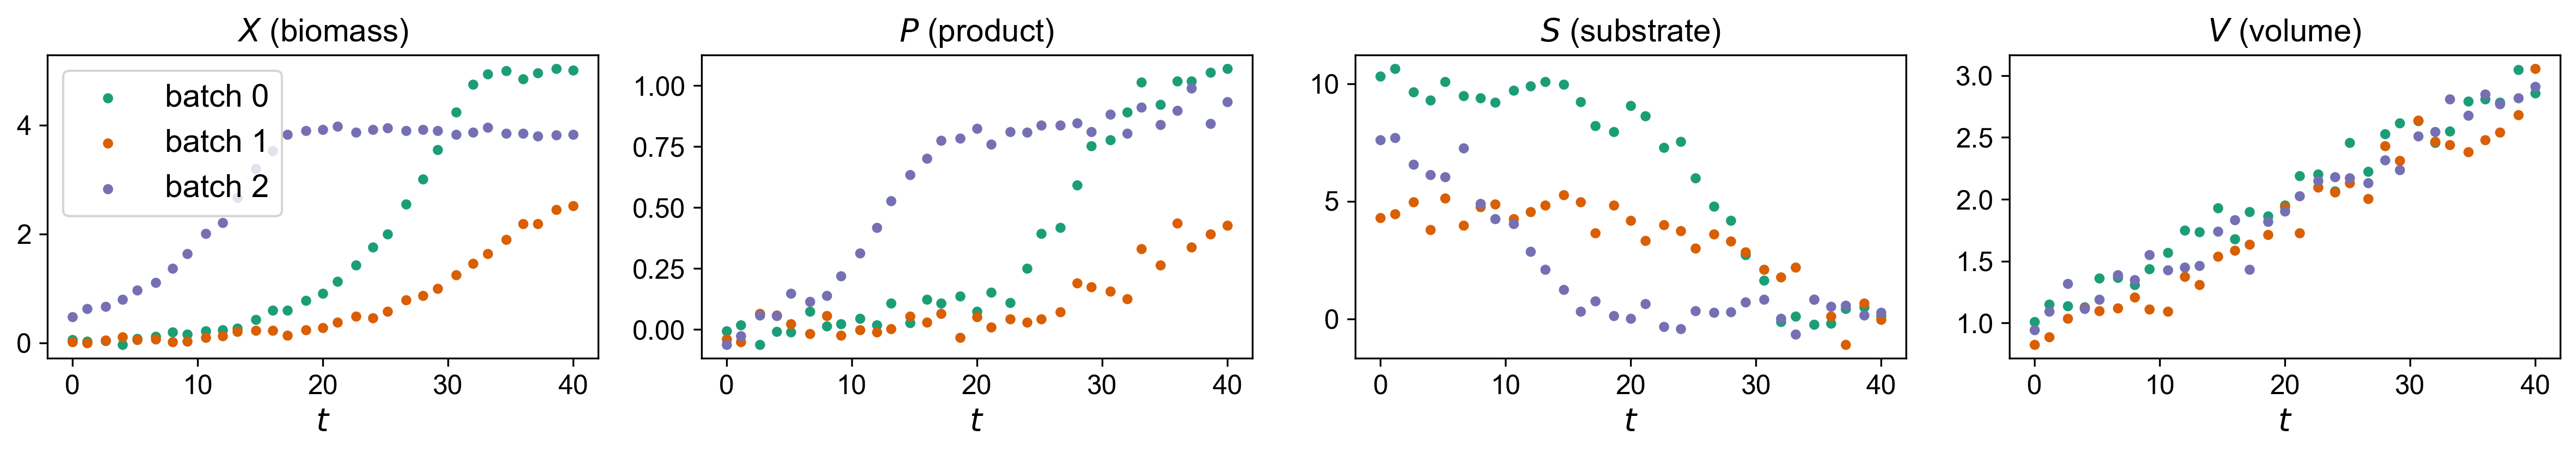

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for j, name in enumerate(STATE_NAMES):
    for b in range(len(obs_times)):
        axes[j].scatter(obs_times[b], obs_values[b][:, j], s=12, label=f'batch {b}')
    axes[j].set_title(name)
    axes[j].set_xlabel('$t$')
axes[0].legend()
plt.tight_layout()
plt.show()

## Step 2 - Define the Network and Train the Hybrid Model

The network maps the four states ($X, P, S, V$) to the scalar growth rate $\mu$, via $z(t) = \mu(t) = f_{NN}\big(X, P, S, V;\ \theta\big)$. As in the other examples we first solve the smoother (a data-fitting NLP with $\mu$ free) to obtain smooth state and $\mu$ trajectories, then pre-train the network on those pairs so the main solve starts from a sensible point.

For this example, we'll train with the simultaneous approach. The bioreactor ODEs contain ratio terms ($\frac{P}{X}$, $\frac{X}{V}$) whose exact Hessian is awkward, so we use the grey-box variant with a limited-memory (L-BFGS) Hessian. See the [Simultaneous Solver](../simultaneous_solver.md) page for the trade-offs.

In [7]:
## Define the MLP ##
mlp = SimpleMLP(
    in_size=problem.input_dim,
    out_size=problem.z_dim,
    widths=[20, 20],
    activations=[jax.nn.softplus] * 2,
    key=jax.random.PRNGKey(SEED),
)

## Smoother solve params ##
REG_COEF = 10.0

smoother_config = SmootherConfig(
    smooth_coef=REG_COEF
)

## Pretraining config ##
PT_EPOCHS = 200
PT_BS = 32
PT_REG_COEF = 1e-3

pretrain_config = PretrainConfig(
    epochs=PT_EPOCHS, 
    batch_size=PT_BS, 
    reg_coef=PT_REG_COEF
    )

## Simultaneous approach config ##
USE_GBM = True
REG_COEF = 1e-3

simul_cfg = SimultaneousConfig(
    use_gbm=USE_GBM, 
    reg_coef=REG_COEF
    )

POUNCE_TOL = 1e-6
POUNCE_MAX_ITER = 1000
HESS_APPROX = 'limited-memory' # L-BFGS hessian approximation setting

solver_options = SolverConfig(
    tol=POUNCE_TOL, 
    max_iter=POUNCE_MAX_ITER, 
    hessian_approximation=HESS_APPROX,
)

# Set up HybridDAE
model = HybridDAE(
    method="simultaneous",
    nlp_solver="pounce",   
    net=mlp,
    smoother=smoother_config,
    pretrain=pretrain_config,
    train=simul_cfg,
    solver_options=solver_options,
    unfix_io=True
)

# Solve problem and train model
model.fit(problem)

# Extract solutions
smoother_data = model.smoother_data
trained_data = model.trained_data

=== Building smoother for 3 trajectories (smooth_coef=10.0) ===
  Smoother: warning / maxIterations
/var/folders/bd/5y876_fs4td3chn71x256drh0000gn/T/ipykernel_51779/2582247566.py:60: UserWarning: HybridDAE smoother solve terminated with 'maxIterations' (not optimal); results may be unreliable.
  model.fit(problem)
=== Building simultaneous GBM model for 3 trajectories ===
=== Solving simultaneous GBM model (pounce, L-BFGS) ===
  pounce: ok / optimal
=== Simultaneous solve complete ===


The fitted state trajectories should pass through the measurement data, and the learned $\mu$ should track the Monod curve we set aside earlier:

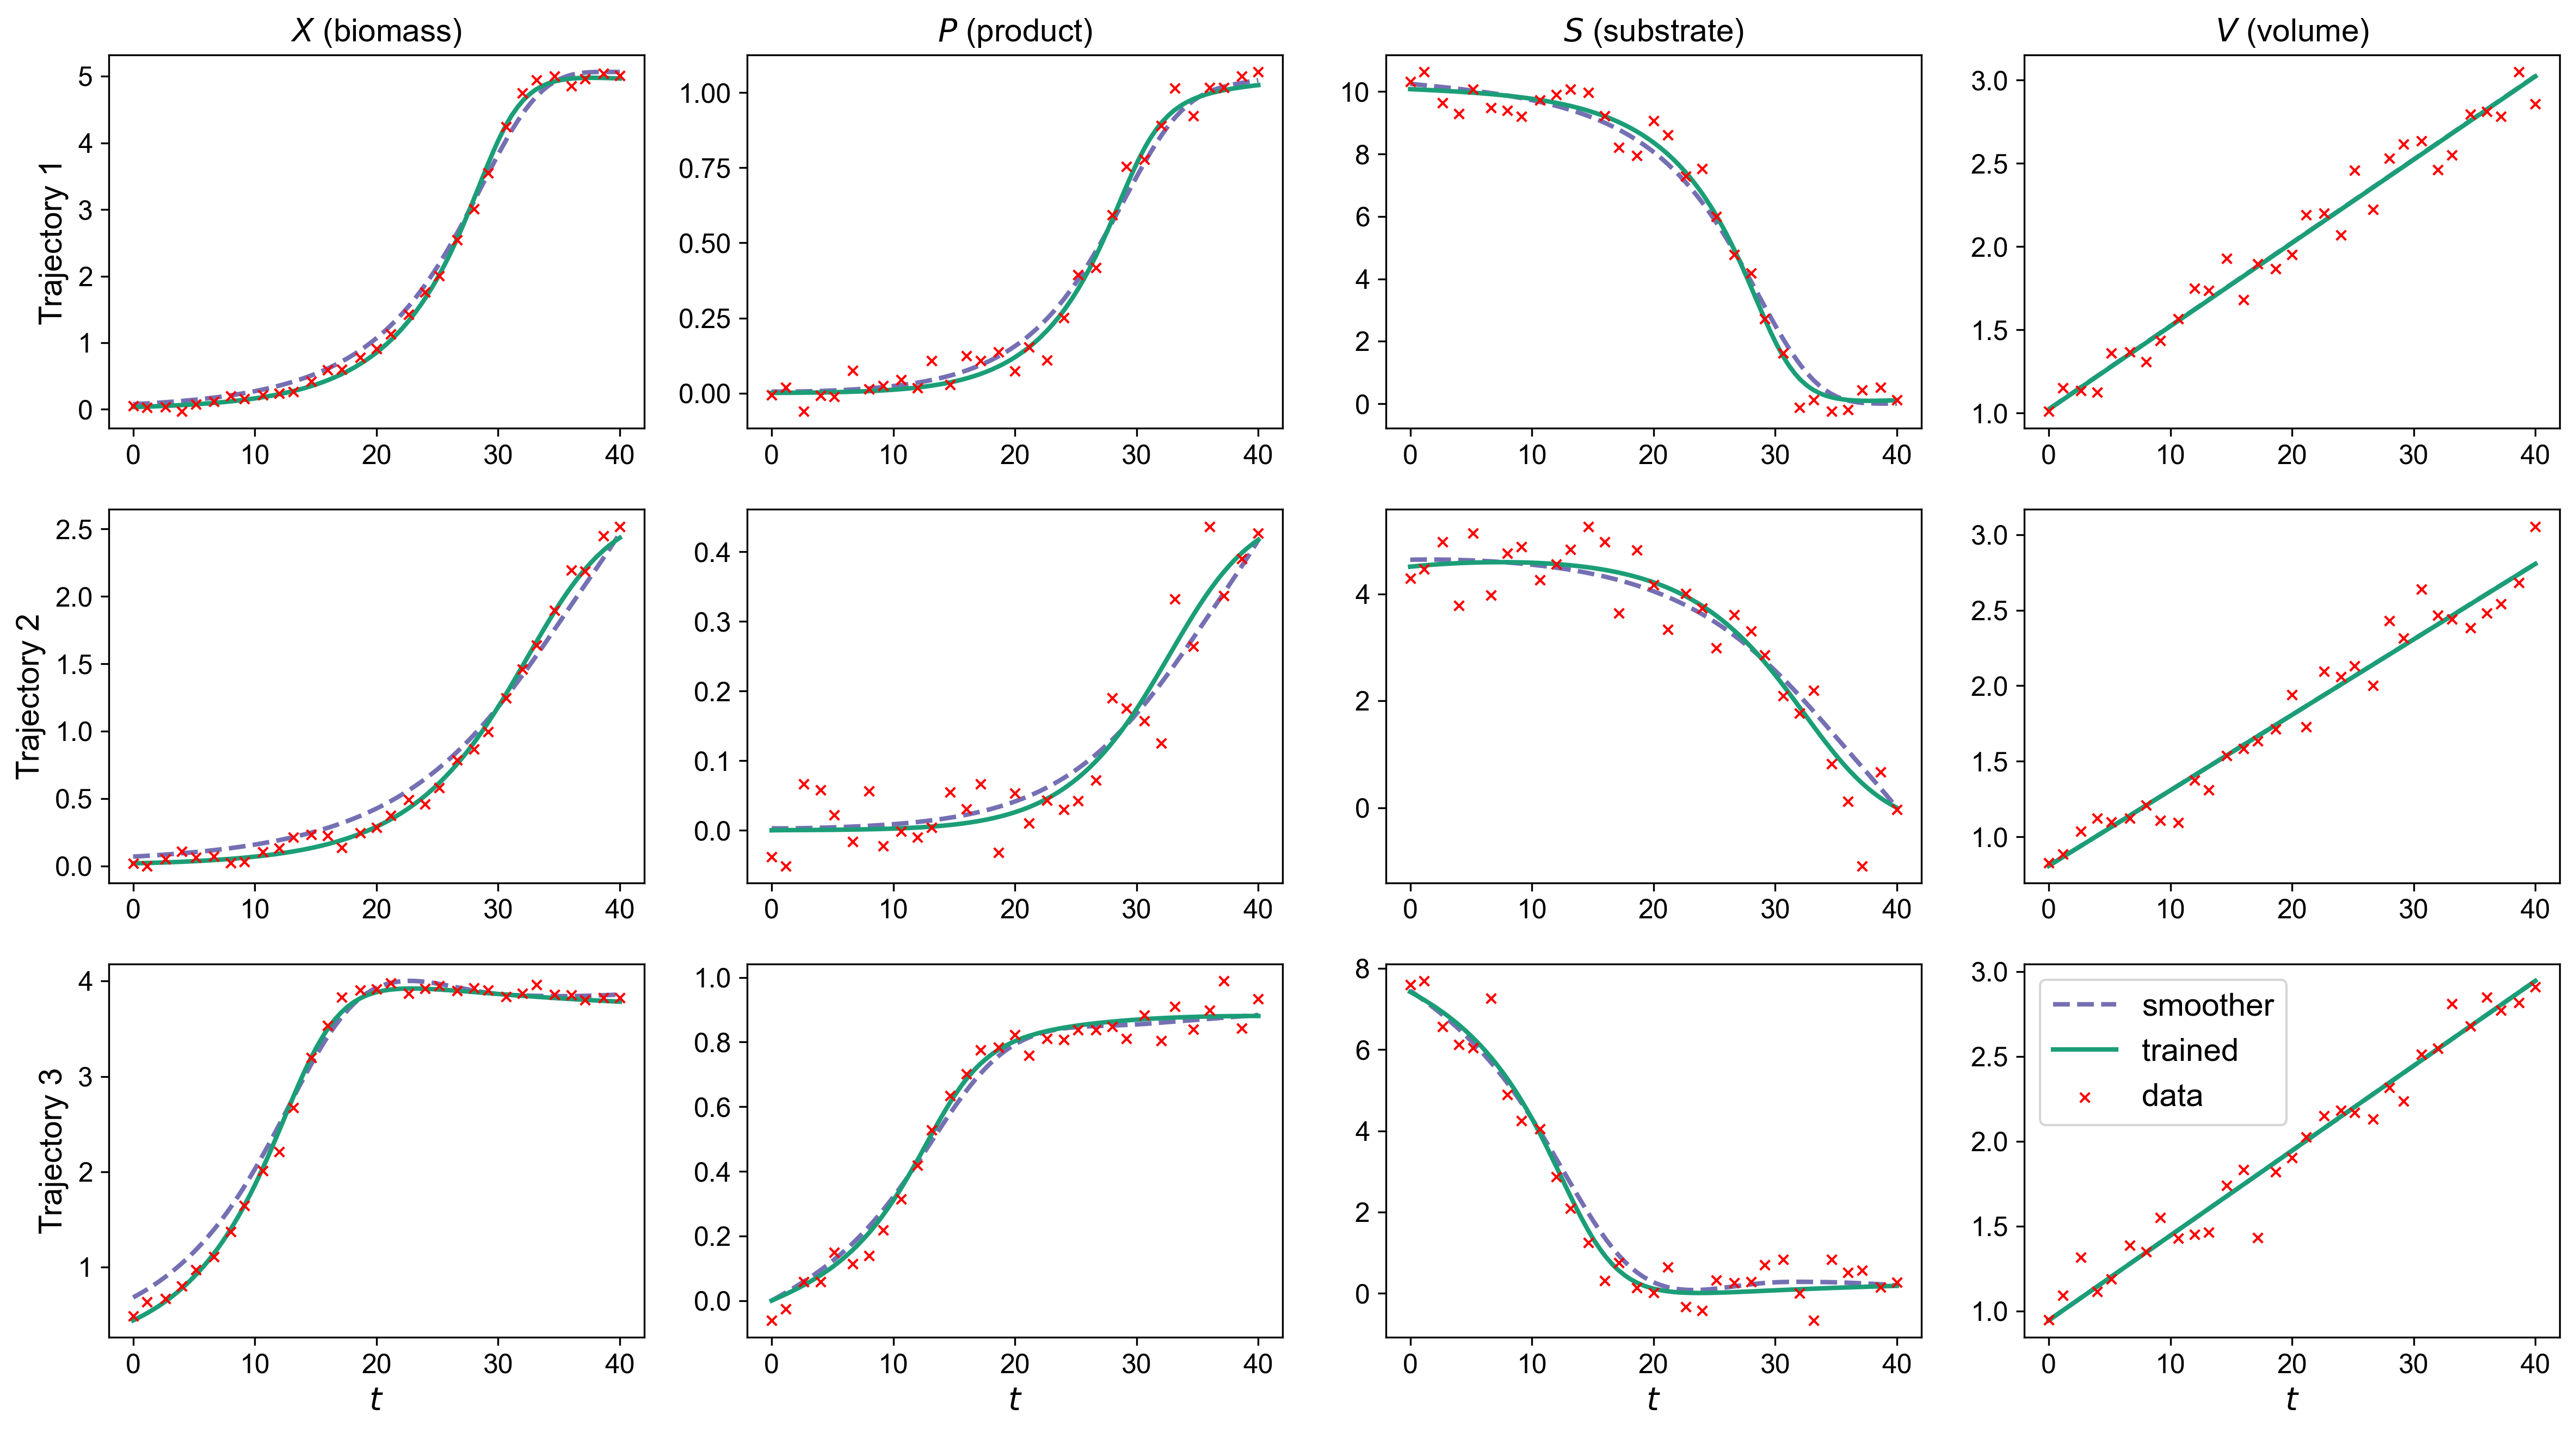

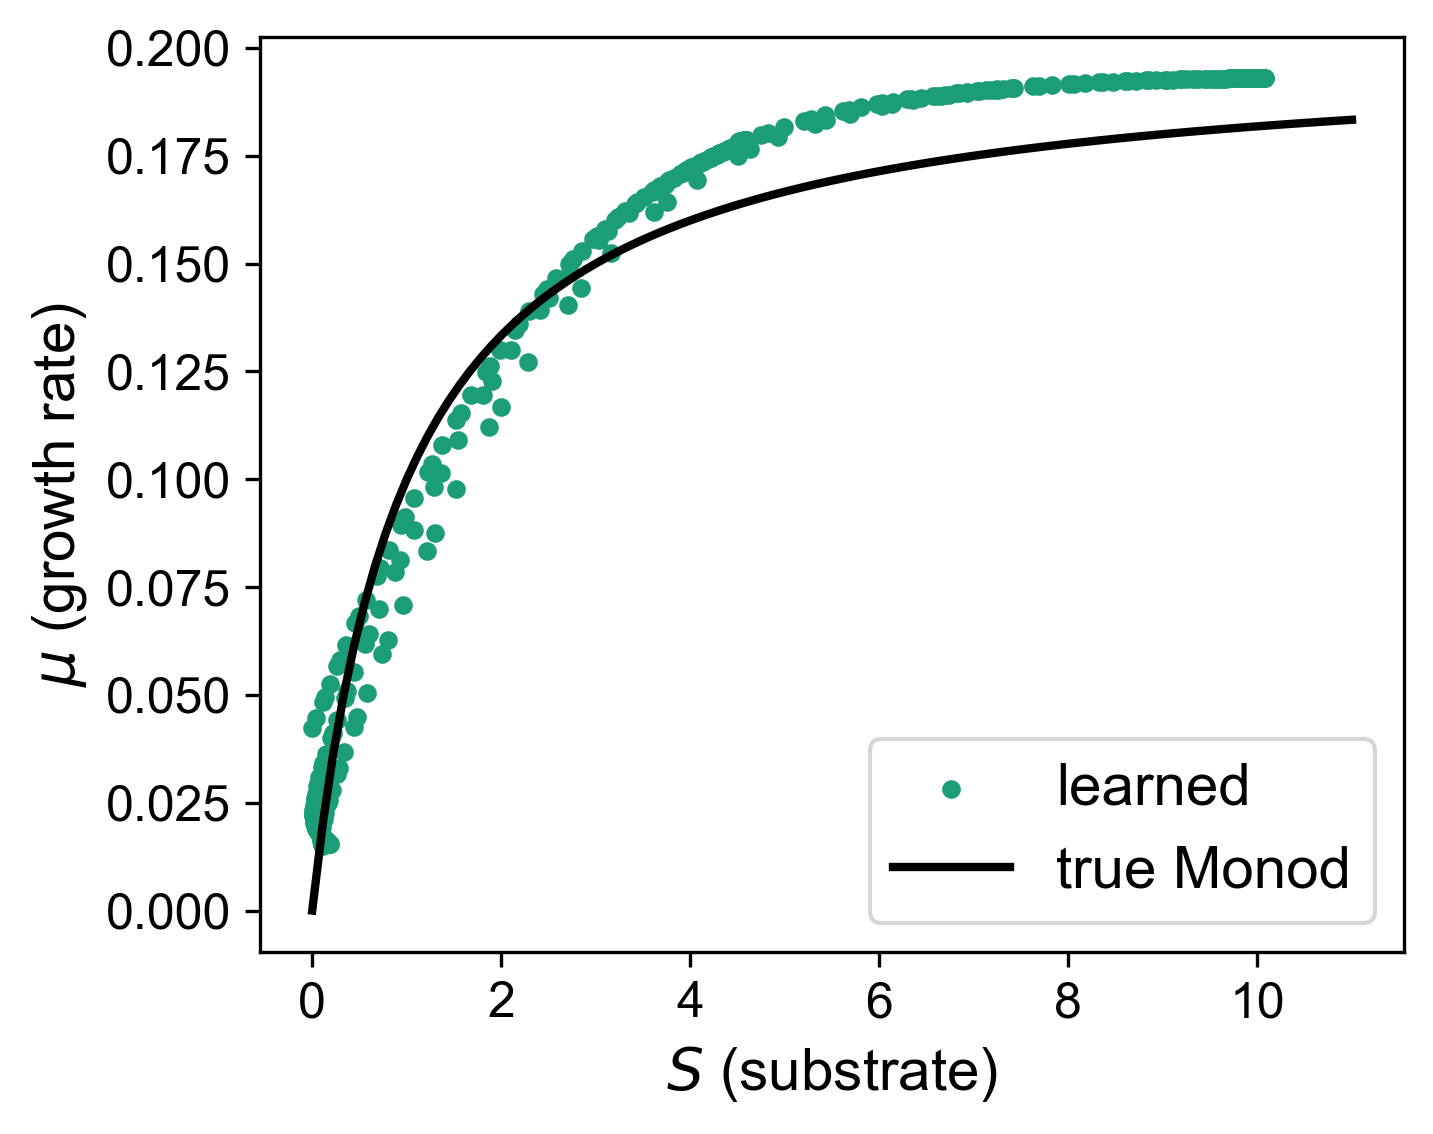

In [8]:
datasets = [
    (smoother_data, 'smoother', {'color': 'C2', 'ls': '--'}),
    (trained_data,  'trained',  {'color': 'C0', 'ls': '-'}),
]

fig_x, _ = plot_instance_data(
    datasets=datasets,
    nn_input_names=STATE_NAMES, nn_output_names=OUTPUT_NAME,
    obs_times=problem.obs_times, obs_values=problem.obs_values,
    obs_names=STATE_NAMES, groups=['inputs'], legend_placement='last',
)
plt.show()

## Learned growth rate vs the true Monod law, plotted against substrate ##
fig_mu, ax = plt.subplots(figsize=(5, 4))
for b in range(problem.num_trajectories):
    S = trained_data[b].nn_input[:, 2]
    ax.scatter(S, trained_data[b].nn_output[:, 0], s=12, color='C0',
               label='learned' if b == 0 else None)
S_grid = np.linspace(0, 11, 100)
ax.plot(S_grid, FB_PARAMS['mu_max'] * S_grid / (FB_PARAMS['Ks'] + S_grid),
        'k-', label='true Monod')
ax.set_xlabel('$S$ (substrate)')
ax.set_ylabel(r'$\mu$ (growth rate)')
ax.legend()
plt.tight_layout()
plt.show()

## Step 4 - Predict new batches under new operating conditions

The learned $\mu(\cdot)$ is now a fixed component embedded inside the mechanistic ODEs. To predict a new batch we build the same problem with a different initial charge and call `solve_inference()`, which holds the network fixed and solves the DAE forward.

Because the conservation equations are enforced as hard constraints and the states are declared non-negative, the predictions stay physically feasible (concentrations $\geq 0$, volume rising at the feed rate) even for initial conditions never seen in training. 

As in previous examples, the discretization domain can be altered from that which was used for training.

In [9]:
## Two unseen initial charges (different starting biomass / substrate / volume) ##
PRED_ICS = np.array([
    [0.20, 0.0, 7.0, 0.90],
    [0.40, 0.0, 6.5, 0.90],
])

# Can change the discretization scheme
PRED_NFE = 30
PRED_NCP = 3

prediction_sets = []
for ic in PRED_ICS:
    new_problem = FedBatchBioreactorProblem(
        params=FB_PARAMS, 
        ics=np.array([ic]),
        input_dim=INPUT_DIM, 
        z_dim=Z_DIM, 
        t_span=T_SPAN,
        nfe=PRED_NFE,
        ncp=PRED_NCP, 
        obs_dim=OBS_DIM,
    )
    
    # Predict using trained model
    inference_m = model.predict(new_problem,
                                slack_coef=1e-5)
    
    prediction_sets.append(inference_m)

## Confirm physical feasibility ##
for ic, pred in zip(PRED_ICS, prediction_sets):
    states = pred[0].nn_input
    mu = pred[0].nn_output[:, 0]
    print(f'IC {ic.tolist()}:  min state = {states.min():.3f} (>= 0),  '
          f'mu in [{mu.min():.3f}, {mu.max():.3f}]')

=== Building inference model for 1 trajectories (slack_coef=1e-05) ===
=== Solving inference model ===
  Inference: ok / optimal
=== Building inference model for 1 trajectories (slack_coef=1e-05) ===
=== Solving inference model ===
  Inference: ok / optimal


IC [0.2, 0.0, 7.0, 0.9]:  min state = 0.000 (>= 0),  mu in [0.016, 0.190]
IC [0.4, 0.0, 6.5, 0.9]:  min state = 0.000 (>= 0),  mu in [0.017, 0.189]


The predicted trajectories for the two new batches, with non-negative concentrations and a steadily rising volume, and no measured data to lean on:

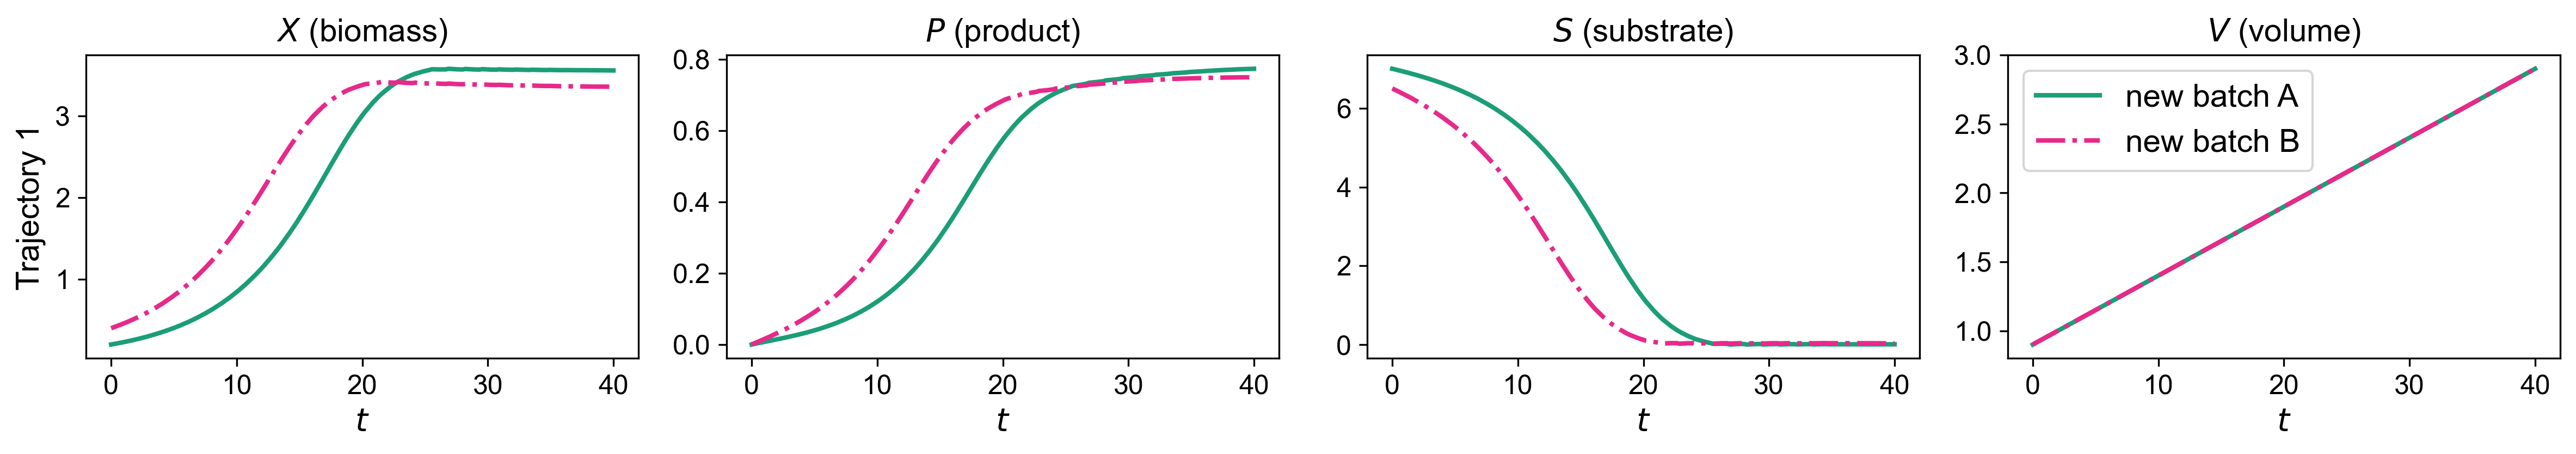

In [10]:
pred_datasets = [
    (prediction_sets[0], 'new batch A', {'color': 'C0', 'ls': '-'}),
    (prediction_sets[1], 'new batch B', {'color': 'C3', 'ls': '-.'}),
]
fig_pred, _ = plot_instance_data(
    datasets=pred_datasets,
    nn_input_names=STATE_NAMES, nn_output_names=OUTPUT_NAME,
    groups=['inputs'], legend_placement='last',
)
plt.show()

## (Bonus) Step 5 - Compare to Ground Truth

To demonstrate the accuracy of the trained HybridDAE, we will compare the new operating condition prediction to the ground truth since we know the underlying dynamics for this example.

In [11]:
from sindae.example_problems import FedBatchBioreactorProblem as GTFedBatchProblem
from sindae import generate_data

generate_data: ok / optimal
=== Building inference model for 1 trajectories (slack_coef=1e-05) ===
=== Solving inference model ===
  Inference: ok / optimal


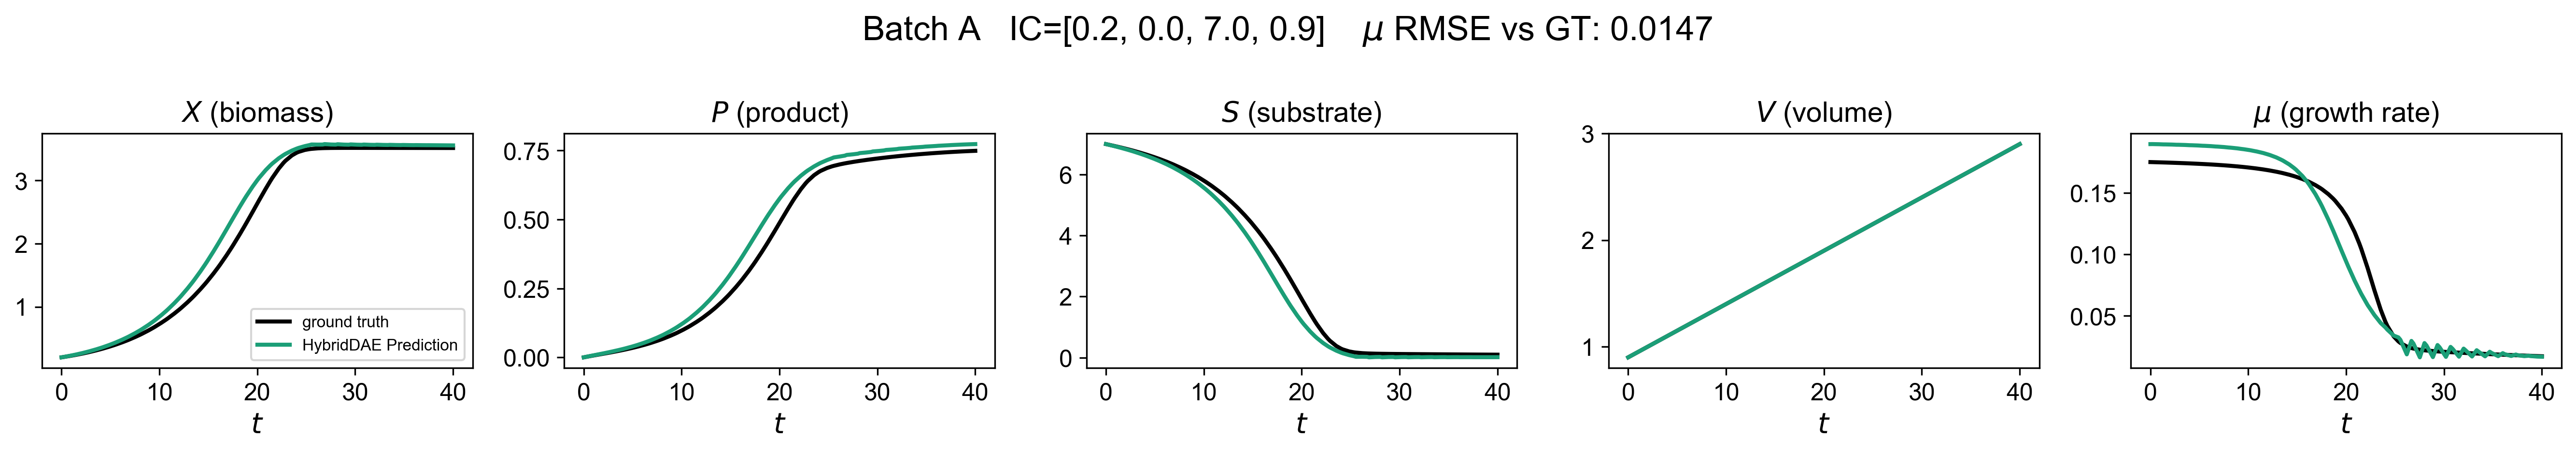

generate_data: ok / optimal
=== Building inference model for 1 trajectories (slack_coef=1e-05) ===
=== Solving inference model ===
  Inference: ok / optimal


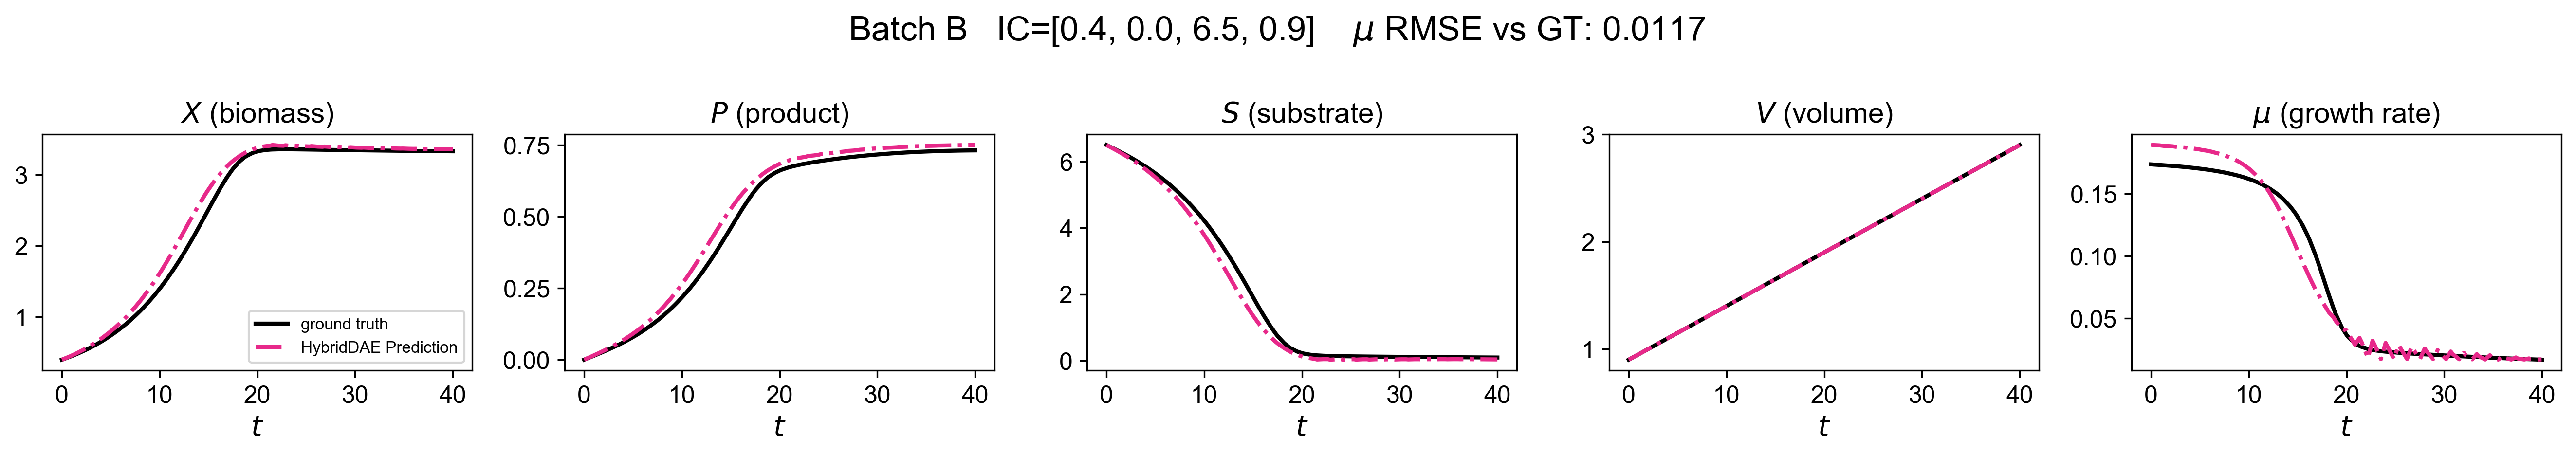

In [12]:
col_names = STATE_NAMES + OUTPUT_NAME          # X, P, S, V, mu

def _feat(traj):
    return np.column_stack([traj.nn_input, traj.nn_output])

def _rmse_vs_gt(pred, gt):
    fp, fg = _feat(pred), _feat(gt)
    return [float(np.sqrt(np.mean(
                (fp[:, k] - np.interp(pred.sampling_times, gt.sampling_times, fg[:, k])) ** 2)))
            for k in range(fp.shape[1])]

for b, ic in enumerate(PRED_ICS):
    # Prediction problem (same inline class / grid as Step 4)
    new_problem = FedBatchBioreactorProblem(
        params=FB_PARAMS, ics=np.array([ic]),
        input_dim=INPUT_DIM, z_dim=Z_DIM, t_span=T_SPAN,
        nfe=PRED_NFE, ncp=PRED_NCP, obs_dim=OBS_DIM,
    )

    # Ground truth: true Monod model solved on the same grid
    gt_problem = GTFedBatchProblem(
        ics=np.array([ic]), params=FB_PARAMS, t_span=T_SPAN,
        nfe=PRED_NFE, ncp=PRED_NCP,
    )
    gt_data = generate_data(gt_problem, noise_std=None)     # noiseless true trajectory

    gt = gt_data[0]

    # Predict using trained model on new problem
    pred = model.predict(new_problem, slack_coef=1e-5)[0]

    rmse = _rmse_vs_gt(pred, gt)

    fig, axes = plt.subplots(1, 5, figsize=(18, 3.2))
    for k, ax in enumerate(axes):
        ax.plot(gt.sampling_times,     _feat(gt)[:, k],     'k-',   lw=2, label='ground truth')
        if b == 0:
            ax.plot(pred.sampling_times, _feat(pred)[:, k], 'C0', ls='-',  ms=4, mfc='none', label='HybridDAE Prediction')
        else:
            ax.plot(pred.sampling_times, _feat(pred)[:, k], 'C3', ls='-.',  ms=4, mfc='none', label='HybridDAE Prediction')
        ax.set_title(col_names[k])
        ax.set_xlabel('$t$')
    axes[0].legend(fontsize=8)
    fig.suptitle(f'Batch {chr(65 + b)}   IC={ic.tolist()}    '
                 f'$\\mu$ RMSE vs GT: {rmse[-1]:.4f} ')
    fig.tight_layout()
    plt.show()


## Summary

This example walked through the bring-your-own-data workflow end to end:

- measurements live in a plain CSV and become `obs_times` / `obs_values` with a few lines of pandas, with no synthetic data generation and no ground-truth kinetics in the problem.
- the known initial charges are supplied directly, and the time series drives the fit.
- once trained, the hybrid model predicts unseen batches with `solve_inference()` while respecting the mechanistic conservation laws, keeping the predictions physically feasible.

{cite}`lueg2025simultaneous`